<a href="https://colab.research.google.com/github/ruudtje21/html-portofolio/blob/main/Penilaian_Kualitas_Udara_dan_Polusi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Tentang Dataset
Kumpulan data ini berfokus pada penilaian kualitas udara di berbagai wilayah. Kumpulan data ini berisi 5000 sampel dan mencakup faktor lingkungan dan demografi penting yang memengaruhi tingkat polusi.

Fitur Utama:

- Suhu (°C): Suhu rata-rata suatu wilayah.
- Kelembaban (%): Kelembaban relatif yang tercatat di wilayah tersebut.
- Konsentrasi PM2.5 (µg/m³): Tingkat partikel halus.
- Konsentrasi PM10 (µg/m³): Tingkat partikel kasar.
- Konsentrasi NO2 (ppb): Tingkat nitrogen dioksida.
- Konsentrasi SO2 (ppb): Tingkat sulfur dioksida.
- Konsentrasi CO (ppm): Tingkat karbon monoksida.
- Kedekatan dengan Kawasan Industri (km): Jarak ke kawasan industri terdekat.
- Kepadatan Penduduk (orang/km²): Jumlah orang per kilometer persegi di wilayah
  tersebut.
- Variabel Target: Tingkat Kualitas Udara

  - Baik: Udara bersih dengan tingkat polusi rendah.
  - Sedang: Kualitas udara dapat diterima tetapi mengandung beberapa polutan.
  - Buruk: Polusi nyata yang dapat menimbulkan masalah kesehatan bagi kelompok sensitif.

Berbahaya: Udara yang sangat tercemar menimbulkan risiko kesehatan serius bagi penduduk.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
airquality_df = pd.read_csv('updated_pollution_dataset.csv')

In [3]:
airquality_df.head()

,Temperature,Humidity,PM2.5,PM10,NO2,SO2,CO,Proximity_to_Industrial_Areas,Population_Density,Air Quality
0,29.8,59.1,5.2,17.9,18.9,9.2,1.72,6.3,319,Moderate
1,28.3,75.6,2.3,12.2,30.8,9.7,1.64,6.0,611,Moderate
2,23.1,74.7,26.7,33.8,24.4,12.6,1.63,5.2,619,Moderate
3,27.1,39.1,6.1,6.3,13.5,5.3,1.15,11.1,551,Good
4,26.5,70.7,6.9,16.0,21.9,5.6,1.01,12.7,303,Good


In [4]:
airquality_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Temperature                    5000 non-null   float64
 1   Humidity                       5000 non-null   float64
 2   PM2.5                          5000 non-null   float64
 3   PM10                           5000 non-null   float64
 4   NO2                            5000 non-null   float64
 5   SO2                            5000 non-null   float64
 6   CO                             5000 non-null   float64
 7   Proximity_to_Industrial_Areas  5000 non-null   float64
 8   Population_Density             5000 non-null   int64  
 9   Air Quality                    5000 non-null   object 
dtypes: float64(8), int64(1), object(1)
memory usage: 390.8+ KB


In [5]:
airquality_df.describe()

,Temperature,Humidity,PM2.5,PM10,NO2,SO2,CO,Proximity_to_Industrial_Areas,Population_Density
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,30.029020,70.056120,20.142140,30.218360,26.412100,10.014820,1.500354,8.425400,497.423800
std,6.720661,15.863577,24.554546,27.349199,8.895356,6.750303,0.546027,3.610944,152.754084
min,13.400000,36.000000,0.000000,-0.200000,7.400000,-6.200000,0.650000,2.500000,188.000000
25%,25.100000,58.300000,4.600000,12.300000,20.100000,5.100000,1.030000,5.400000,381.000000
50%,29.000000,69.800000,12.000000,21.700000,25.300000,8.000000,1.410000,7.900000,494.000000
75%,34.000000,80.300000,26.100000,38.100000,31.900000,13.725000,1.840000,11.100000,600.000000
max,58.600000,128.100000,295.000000,315.800000,64.900000,44.900000,3.720000,25.800000,957.000000


In [6]:
airquality_df.isnull().sum()

,0
Temperature,0
Humidity,0
PM2.5,0
PM10,0
NO2,0
SO2,0
CO,0
Proximity_to_Industrial_Areas,0
Population_Density,0
Air Quality,0


In [7]:
airquality_df.duplicated().sum()

0

In [8]:
airquality_df.corr(numeric_only=True)

,Temperature,Humidity,PM2.5,PM10,NO2,SO2,CO,Proximity_to_Industrial_Areas,Population_Density
Temperature,1.000000,0.466456,0.323840,0.425690,0.591969,0.568082,0.685258,-0.589564,0.481692
Humidity,0.466456,1.000000,0.273366,0.359156,0.491977,0.459804,0.567540,-0.479646,0.411630
PM2.5,0.323840,0.273366,1.000000,0.973005,0.333004,0.299582,0.395179,-0.315766,0.278957
PM10,0.425690,0.359156,0.973005,1.000000,0.439916,0.401849,0.518895,-0.425018,0.365734
NO2,0.591969,0.491977,0.333004,0.439916,1.000000,0.571839,0.710792,-0.607710,0.510938
SO2,0.568082,0.459804,0.299582,0.401849,0.571839,1.000000,0.679060,-0.570385,0.475242
CO,0.685258,0.567540,0.395179,0.518895,0.710792,0.679060,1.000000,-0.707581,0.593389
Proximity_to_Industrial_Areas,-0.589564,-0.479646,-0.315766,-0.425018,-0.607710,-0.570385,-0.707581,1.000000,-0.498058
Population_Density,0.481692,0.411630,0.278957,0.365734,0.510938,0.475242,0.593389,-0.498058,1.000000


In [9]:
airquality_df.corr(numeric_only=True).style.background_gradient(cmap='coolwarm')

,Temperature,Humidity,PM2.5,PM10,NO2,SO2,CO,Proximity_to_Industrial_Areas,Population_Density
Temperature,1.000000,0.466456,0.323840,0.425690,0.591969,0.568082,0.685258,-0.589564,0.481692
Humidity,0.466456,1.000000,0.273366,0.359156,0.491977,0.459804,0.567540,-0.479646,0.411630
PM2.5,0.323840,0.273366,1.000000,0.973005,0.333004,0.299582,0.395179,-0.315766,0.278957
PM10,0.425690,0.359156,0.973005,1.000000,0.439916,0.401849,0.518895,-0.425018,0.365734
NO2,0.591969,0.491977,0.333004,0.439916,1.000000,0.571839,0.710792,-0.607710,0.510938
SO2,0.568082,0.459804,0.299582,0.401849,0.571839,1.000000,0.679060,-0.570385,0.475242
CO,0.685258,0.567540,0.395179,0.518895,0.710792,0.679060,1.000000,-0.707581,0.593389
Proximity_to_Industrial_Areas,-0.589564,-0.479646,-0.315766,-0.425018,-0.607710,-0.570385,-0.707581,1.000000,-0.498058
Population_Density,0.481692,0.411630,0.278957,0.365734,0.510938,0.475242,0.593389,-0.498058,1.000000


In [10]:
airquality_df.columns

Index(['Temperature', 'Humidity', 'PM2.5', 'PM10', 'NO2', 'SO2', 'CO',
       'Proximity_to_Industrial_Areas', 'Population_Density', 'Air Quality'],
      dtype='object')

In [11]:
airquality_df.shape

(5000, 10)

In [12]:
airquality_df.dtypes

,0
Temperature,float64
Humidity,float64
PM2.5,float64
PM10,float64
NO2,float64
SO2,float64
CO,float64
Proximity_to_Industrial_Areas,float64
Population_Density,int64
Air Quality,object


In [13]:
airquality_df.nunique()

,0
Temperature,362
Humidity,723
PM2.5,815
PM10,955
NO2,445
SO2,348
CO,265
Proximity_to_Industrial_Areas,179
Population_Density,683
Air Quality,4


In [14]:
y = airquality_df['Air Quality']

In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(airquality_df, y, test_size=0.2, random_state=42)

In [16]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((4000, 10), (1000, 10), (4000,), (1000,))

In [18]:
X = airquality_df.drop('Air Quality', axis=1)
y = airquality_df['Air Quality']

In [19]:
X.shape

(5000, 9)

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)


In [21]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()

In [23]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
categorical_features = ['Air Quality']
one_hot = OneHotEncoder()
transformer = ColumnTransformer([('one_hot', one_hot, categorical_features)], remainder='passthrough')
transformed_X = transformer.fit_transform(airquality_df)
transformed_X

array([[  0.  ,   0.  ,   1.  , ...,   1.72,   6.3 , 319.  ],
       [  0.  ,   0.  ,   1.  , ...,   1.64,   6.  , 611.  ],
       [  0.  ,   0.  ,   1.  , ...,   1.63,   5.2 , 619.  ],
       ...,
       [  0.  ,   0.  ,   1.  , ...,   1.63,   9.6 , 379.  ],
       [  1.  ,   0.  ,   0.  , ...,   0.89,  11.6 , 241.  ],
       [  0.  ,   0.  ,   1.  , ...,   1.38,   8.3 , 461.  ]])

In [24]:
pd.DataFrame(transformed_X)

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,0.0,0.0,1.0,0.0,29.8,59.1,5.2,17.9,18.9,9.2,1.72,6.3,319.0
1,0.0,0.0,1.0,0.0,28.3,75.6,2.3,12.2,30.8,9.7,1.64,6.0,611.0
2,0.0,0.0,1.0,0.0,23.1,74.7,26.7,33.8,24.4,12.6,1.63,5.2,619.0
3,1.0,0.0,0.0,0.0,27.1,39.1,6.1,6.3,13.5,5.3,1.15,11.1,551.0
4,1.0,0.0,0.0,0.0,26.5,70.7,6.9,16.0,21.9,5.6,1.01,12.7,303.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,0.0,1.0,0.0,0.0,40.6,74.1,116.0,126.7,45.5,25.7,2.11,2.8,765.0
4996,0.0,0.0,1.0,0.0,28.1,96.9,6.9,25.0,25.3,10.8,1.54,5.7,709.0
4997,0.0,0.0,1.0,0.0,25.9,78.2,14.2,22.1,34.8,7.8,1.63,9.6,379.0
4998,1.0,0.0,0.0,0.0,25.3,44.4,21.4,29.0,23.7,5.7,0.89,11.6,241.0


In [25]:
dummies = pd.get_dummies(airquality_df['Air Quality'])
dummies

,Good,Hazardous,Moderate,Poor
0,False,False,True,False
1,False,False,True,False
2,False,False,True,False
3,True,False,False,False
4,True,False,False,False
...,...,...,...,...
4995,False,True,False,False
4996,False,False,True,False
4997,False,False,True,False
4998,True,False,False,False


In [26]:
np.random.seed(42)
X_train, X_test, y_train, y_test = train_test_split(transformed_X, y, test_size=0.2)
model.fit(X_train, y_train)


RandomForestClassifier()

In [27]:
model.score(X_test, y_test)


1.0

In [29]:
# Import the RandomForestClassifier estimator class
from sklearn.ensemble import RandomForestClassifier

# Setup random seed
np.random.seed(42)

# Make the data
X = airquality_df.drop('Air Quality', axis=1)
y = airquality_df['Air Quality']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Instantiate the RandomForestClassifier model
clf = RandomForestClassifier()
clf.fit(X_train, y_train)

# Check the accuracy
clf.score(X_test, y_test)

0.956

In [30]:
X.head()

,Temperature,Humidity,PM2.5,PM10,NO2,SO2,CO,Proximity_to_Industrial_Areas,Population_Density
0,29.8,59.1,5.2,17.9,18.9,9.2,1.72,6.3,319
1,28.3,75.6,2.3,12.2,30.8,9.7,1.64,6.0,611
2,23.1,74.7,26.7,33.8,24.4,12.6,1.63,5.2,619
3,27.1,39.1,6.1,6.3,13.5,5.3,1.15,11.1,551
4,26.5,70.7,6.9,16.0,21.9,5.6,1.01,12.7,303


In [31]:
y.head()

,Air Quality
0,Moderate
1,Moderate
2,Moderate
3,Good
4,Good


In [32]:
y.tail()

,Air Quality
4995,Hazardous
4996,Moderate
4997,Moderate
4998,Good
4999,Moderate


In [33]:
clf.predict(X_test)

array(['Hazardous', 'Good', 'Moderate', 'Hazardous', 'Good', 'Hazardous',
       'Good', 'Good', 'Good', 'Moderate', 'Moderate', 'Good',
       'Hazardous', 'Good', 'Moderate', 'Good', 'Good', 'Good',
       'Moderate', 'Poor', 'Good', 'Good', 'Poor', 'Moderate', 'Good',
       'Poor', 'Good', 'Good', 'Moderate', 'Moderate', 'Good', 'Poor',
       'Moderate', 'Moderate', 'Moderate', 'Poor', 'Moderate', 'Moderate',
       'Moderate', 'Good', 'Poor', 'Moderate', 'Hazardous', 'Good',
       'Good', 'Moderate', 'Moderate', 'Poor', 'Good', 'Good', 'Moderate',
       'Good', 'Good', 'Good', 'Good', 'Moderate', 'Hazardous',
       'Moderate', 'Poor', 'Good', 'Good', 'Good', 'Good', 'Moderate',
       'Good', 'Poor', 'Poor', 'Good', 'Moderate', 'Moderate', 'Good',
       'Good', 'Poor', 'Good', 'Good', 'Moderate', 'Moderate', 'Moderate',
       'Good', 'Good', 'Good', 'Poor', 'Poor', 'Good', 'Moderate',
       'Moderate', 'Hazardous', 'Moderate', 'Moderate', 'Poor',
       'Moderate', 'Good', 

In [34]:
np.array([X_test])

array([[[ 31.3 ,  73.4 ,  72.8 , ...,   2.54,   2.6 , 755.  ],
        [ 24.  ,  68.8 ,   0.8 , ...,   1.16,  10.5 , 235.  ],
        [ 25.4 ,  78.6 ,   4.1 , ...,   1.4 ,  10.1 , 543.  ],
        ...,
        [ 30.9 ,  92.5 ,  24.3 , ...,   1.64,   9.1 , 678.  ],
        [ 27.8 ,  83.6 ,  23.7 , ...,   1.22,   7.4 , 420.  ],
        [ 30.6 , 107.4 ,  35.4 , ...,   1.73,   5.6 , 631.  ]]])

In [35]:
np.array([y_test])

array([['Hazardous', 'Good', 'Moderate', 'Hazardous', 'Good',
        'Hazardous', 'Good', 'Good', 'Good', 'Moderate', 'Moderate',
        'Good', 'Poor', 'Good', 'Moderate', 'Good', 'Good', 'Good',
        'Moderate', 'Poor', 'Good', 'Good', 'Poor', 'Moderate', 'Good',
        'Poor', 'Good', 'Good', 'Moderate', 'Moderate', 'Good', 'Poor',
        'Poor', 'Moderate', 'Moderate', 'Moderate', 'Moderate',
        'Moderate', 'Moderate', 'Good', 'Poor', 'Moderate', 'Hazardous',
        'Good', 'Good', 'Moderate', 'Moderate', 'Poor', 'Good', 'Good',
        'Moderate', 'Good', 'Good', 'Good', 'Good', 'Moderate',
        'Hazardous', 'Moderate', 'Poor', 'Good', 'Good', 'Good', 'Good',
        'Moderate', 'Good', 'Hazardous', 'Poor', 'Good', 'Moderate',
        'Moderate', 'Good', 'Good', 'Moderate', 'Good', 'Good',
        'Moderate', 'Moderate', 'Moderate', 'Good', 'Good', 'Good',
        'Poor', 'Poor', 'Good', 'Moderate', 'Moderate', 'Hazardous',
        'Moderate', 'Moderate', 'Poor', '

In [36]:
y_preds = clf.predict(X_test)
np.mean(y_preds == y_test)


0.956

In [37]:
clf.score(X_test, y_test)

0.956

In [38]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_preds)


0.956

In [39]:
clf.predict_proba(X_test[:5])


array([[0.  , 0.89, 0.  , 0.11],
       [1.  , 0.  , 0.  , 0.  ],
       [0.21, 0.  , 0.79, 0.  ],
       [0.  , 0.61, 0.  , 0.39],
       [1.  , 0.  , 0.  , 0.  ]])

In [40]:
clf.predict(X_test[:5])


array(['Hazardous', 'Good', 'Moderate', 'Hazardous', 'Good'], dtype=object)

In [41]:
from sklearn.metrics import confusion_matrix
y_preds = clf.predict(X_test)
confusion_matrix(y_test, y_preds)

array([[409,   0,   0,   0],
       [  0,  97,   0,  14],
       [  0,   0, 284,  10],
       [  0,   9,  11, 166]])

In [42]:
pd.crosstab(y_test, y_preds,
            rownames=['Actual Labels'],
            colnames=['Predicted Labels'])


Predicted Labels,Good,Hazardous,Moderate,Poor
Actual Labels,,,,
Good,409,0,0,0
Hazardous,0,97,0,14
Moderate,0,0,284,10
Poor,0,9,11,166


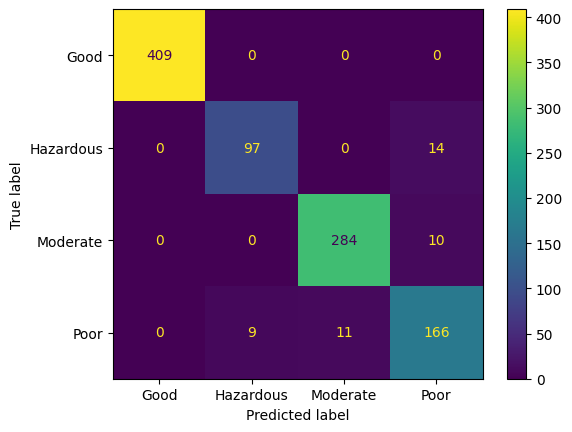

In [43]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test)


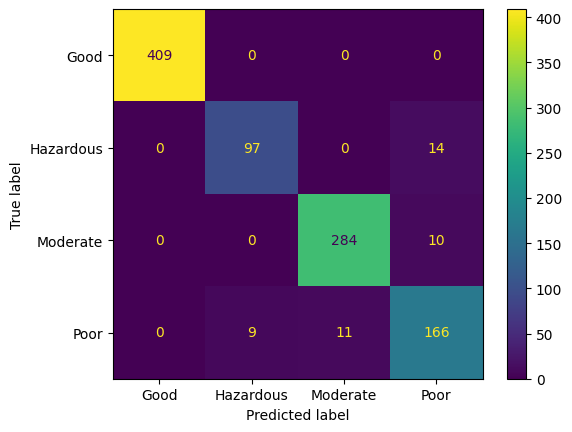

In [44]:
ConfusionMatrixDisplay.from_predictions(y_true=y_test,
                                        y_pred=y_preds)

In [45]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_preds))

              precision    recall  f1-score   support

        Good       1.00      1.00      1.00       409
   Hazardous       0.92      0.87      0.89       111
    Moderate       0.96      0.97      0.96       294
        Poor       0.87      0.89      0.88       186

    accuracy                           0.96      1000
   macro avg       0.94      0.93      0.94      1000
weighted avg       0.96      0.96      0.96      1000



In [ ]:
airquality_df = pd.get_dummies(airquality_df, columns=['Air Quality'])

In [ ]:
categorical_columns = [col for col in airquality_df.columns if col.startswith('Air Quality_')]
print(categorical_columns) # Print to verify the available columns
encoded_features = ohc.fit_transform(airquality_df[categorical_columns])

['Air Quality_Good', 'Air Quality_Hazardous', 'Air Quality_Moderate', 'Air Quality_Poor']


In [ ]:
print(airquality_df.columns)

Index(['Temperature', 'Humidity', 'PM2.5', 'PM10', 'NO2', 'SO2', 'CO',
       'Proximity_to_Industrial_Areas', 'Population_Density',
       'Air Quality_Good', 'Air Quality_Hazardous', 'Air Quality_Moderate',
       'Air Quality_Poor'],
      dtype='object')


In [ ]:
categorical_columns = [col for col in categorical_columns if col in airquality_df.columns]

In [ ]:
airquality_df.head()

,Temperature,Humidity,PM2.5,PM10,NO2,SO2,CO,Proximity_to_Industrial_Areas,Population_Density,Air Quality_Good,Air Quality_Hazardous,Air Quality_Moderate,Air Quality_Poor
0,29.8,59.1,5.2,17.9,18.9,9.2,1.72,6.3,319,False,False,True,False
1,28.3,75.6,2.3,12.2,30.8,9.7,1.64,6.0,611,False,False,True,False
2,23.1,74.7,26.7,33.8,24.4,12.6,1.63,5.2,619,False,False,True,False
3,27.1,39.1,6.1,6.3,13.5,5.3,1.15,11.1,551,True,False,False,False
4,26.5,70.7,6.9,16.0,21.9,5.6,1.01,12.7,303,True,False,False,False


In [ ]:
from sklearn.preprocessing import OneHotEncoder

In [ ]:
ohc = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

In [ ]:
ohc


OneHotEncoder(handle_unknown='ignore', sparse_output=False)

In [ ]:
encoded_features = ohc.fit_transform(airquality_df[categorical_columns])

In [ ]:
encoded_features

array([[1., 0., 1., ..., 1., 1., 0.],
       [1., 0., 1., ..., 1., 1., 0.],
       [1., 0., 1., ..., 1., 1., 0.],
       ...,
       [1., 0., 1., ..., 1., 1., 0.],
       [0., 1., 1., ..., 0., 1., 0.],
       [1., 0., 1., ..., 1., 1., 0.]])

In [ ]:
categorical_columns = [col for col in airquality_df.columns if col.startswith('Air Quality_')]
print(categorical_columns)
ohc = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_features = ohc.fit_transform(airquality_df[categorical_columns])

['Air Quality_Good', 'Air Quality_Hazardous', 'Air Quality_Moderate', 'Air Quality_Poor']
